## PHASE A

In [58]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working directory:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())
print("data exists:", (PROJECT_ROOT / "data").exists())

Current working directory: c:\Users\farha\code\nasa-spacecraft-telemetry\notebooks
Project root: c:\Users\farha\code\nasa-spacecraft-telemetry
src exists: True
data exists: True


In [59]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, train_test_split
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    confusion_matrix,
)

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from src.config import RANDOM_STATE
from src.data.loader import load_labels_metadata
from src.data.dataset_builder import (
    build_supervised_dataset,
    build_unsupervised_dataset,
)
from src.data.splitting import create_outer_channel_split

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
warnings.filterwarnings("ignore", category=RuntimeWarning)

print("All imports loaded successfully.")

All imports loaded successfully.


## PHASE B

In [60]:
# Phase B1: Load the benchmark metadata
labels_df = load_labels_metadata()

print("Metadata shape:", labels_df.shape)
labels_df.head()

Metadata shape: (82, 5)


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505
1,S-1,SMAP,"[[5300, 5747]]",[point],7331
2,E-1,SMAP,"[[5000, 5030], [5610, 6086]]","[contextual, contextual]",8516
3,E-2,SMAP,"[[5598, 6995]]",[point],8532
4,E-3,SMAP,"[[5094, 8306]]",[point],8307


In [61]:
# Phase B2: Rebuild the supervised MSL dataset
msl_supervised = build_supervised_dataset(
    labels_df=labels_df,
    spacecraft="MSL",
)

print("MSL supervised feature df shape:", msl_supervised["feature_df"].shape)
print("MSL channel summary shape:", msl_supervised["channel_summary_df"].shape)
print("Number of MSL channels:", msl_supervised["channel_summary_df"]["chan_id"].nunique())

MSL supervised feature df shape: (14601, 670)
MSL channel summary shape: (27, 5)
Number of MSL channels: 27


In [62]:
# Phase B3: Rebuild the supervised SMAP dataset
smap_supervised = build_supervised_dataset(
    labels_df=labels_df,
    spacecraft="SMAP",
)

print("SMAP supervised feature df shape:", smap_supervised["feature_df"].shape)
print("SMAP channel summary shape:", smap_supervised["channel_summary_df"].shape)
print("Number of SMAP channels:", smap_supervised["channel_summary_df"]["chan_id"].nunique())

SMAP supervised feature df shape: (86873, 310)
SMAP channel summary shape: (54, 5)
Number of SMAP channels: 54


In [63]:
# Phase B4: Check label counts for both datasets
print("MSL label counts:")
print(msl_supervised["feature_df"]["label"].value_counts().sort_index())
print()

print("SMAP label counts:")
print(smap_supervised["feature_df"]["label"].value_counts().sort_index())

MSL label counts:
label
0    12853
1     1748
Name: count, dtype: int64

SMAP label counts:
label
0    75342
1    11531
Name: count, dtype: int64


## PHASE C

In [64]:
# Phase C1: Strict channel-level split for MSL
# Keep the strict split so we can compare unseen-channel generalization against the easier random-window setup
msl_outer_split = create_outer_channel_split(
    channel_summary_df=msl_supervised["channel_summary_df"],
    test_size=0.2,
)

msl_dev_strict_df = msl_supervised["feature_df"][
    msl_supervised["feature_df"]["chan_id"].isin(msl_outer_split["dev_chan_ids"])
].copy()

msl_test_strict_df = msl_supervised["feature_df"][
    msl_supervised["feature_df"]["chan_id"].isin(msl_outer_split["test_chan_ids"])
].copy()

print("Strict split:")
print("  Dev shape:", msl_dev_strict_df.shape)
print("  Test shape:", msl_test_strict_df.shape)
print("  Dev channels:", len(msl_outer_split["dev_chan_ids"]))
print("  Test channels:", len(msl_outer_split["test_chan_ids"]))
print("  Channel overlap:", set(msl_dev_strict_df["chan_id"].unique()).intersection(set(msl_test_strict_df["chan_id"].unique())))

Strict split:
  Dev shape: (10664, 670)
  Test shape: (3937, 670)
  Dev channels: 21
  Test channels: 6
  Channel overlap: set()


In [65]:
# Phase C2: Optimistic random-window split for MSL
# Build the easier random window-level split where train and test can share channels
# This is used as an optimistic comparison rather than the main evaluation setting
msl_full_df = msl_supervised["feature_df"].copy()

msl_train_opt_df, msl_test_opt_df = train_test_split(
    msl_full_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=msl_full_df["label"],
)

print("Optimistic random-window split:")
print("  Train shape:", msl_train_opt_df.shape)
print("  Test shape:", msl_test_opt_df.shape)
print("  Train anomaly ratio:", round(msl_train_opt_df["label"].mean(), 4))
print("  Test anomaly ratio:", round(msl_test_opt_df["label"].mean(), 4))
print("  Channel overlap count:", len(set(msl_train_opt_df["chan_id"].unique()).intersection(set(msl_test_opt_df["chan_id"].unique()))))

Optimistic random-window split:
  Train shape: (11680, 670)
  Test shape: (2921, 670)
  Train anomaly ratio: 0.1197
  Test anomaly ratio: 0.1198
  Channel overlap count: 27


In [66]:
# Phase C3: Define the model feature columns
# Remove identifiers and label-related fields so the models only receive engineered feature inputs
non_feature_cols = [
    "chan_id",
    "split",
    "window_id",
    "start_idx",
    "end_idx",
    "label",
    "has_overlap",
    "num_overlapping_intervals",
    "overlapping_intervals",
    "spacecraft",
]

feature_cols = [col for col in msl_full_df.columns if col not in non_feature_cols]

print("Number of feature columns:", len(feature_cols))
print("First 10 feature columns:", feature_cols[:10])

Number of feature columns: 660
First 10 feature columns: ['mean_v0', 'mean_v1', 'mean_v2', 'mean_v3', 'mean_v4', 'mean_v5', 'mean_v6', 'mean_v7', 'mean_v8', 'mean_v9']


In [67]:
# Phase C4: Build arrays for the strict channel-level split
X_train_strict = msl_dev_strict_df[feature_cols].to_numpy()
y_train_strict = msl_dev_strict_df["label"].to_numpy()
groups_train_strict = msl_dev_strict_df["chan_id"].to_numpy()

X_test_strict = msl_test_strict_df[feature_cols].to_numpy()
y_test_strict = msl_test_strict_df["label"].to_numpy()
groups_test_strict = msl_test_strict_df["chan_id"].to_numpy()

print("Strict train X shape:", X_train_strict.shape)
print("Strict test X shape:", X_test_strict.shape)
print("Strict train anomaly ratio:", round(y_train_strict.mean(), 4))
print("Strict test anomaly ratio:", round(y_test_strict.mean(), 4))

Strict train X shape: (10664, 660)
Strict test X shape: (3937, 660)
Strict train anomaly ratio: 0.1137
Strict test anomaly ratio: 0.1361


In [68]:
# Phase C5: Build arrays for the optimistic random-window split
X_train_opt = msl_train_opt_df[feature_cols].to_numpy()
y_train_opt = msl_train_opt_df["label"].to_numpy()

X_test_opt = msl_test_opt_df[feature_cols].to_numpy()
y_test_opt = msl_test_opt_df["label"].to_numpy()

print("Optimistic train X shape:", X_train_opt.shape)
print("Optimistic test X shape:", X_test_opt.shape)
print("Optimistic train anomaly ratio:", round(y_train_opt.mean(), 4))
print("Optimistic test anomaly ratio:", round(y_test_opt.mean(), 4))

Optimistic train X shape: (11680, 660)
Optimistic test X shape: (2921, 660)
Optimistic train anomaly ratio: 0.1197
Optimistic test anomaly ratio: 0.1198


In [69]:
# Phase C6: Compare the strict and optimistic split sizes side by side
split_compare_df = pd.DataFrame([
    {
        "setup": "Strict channel-level",
        "train_rows": len(y_train_strict),
        "test_rows": len(y_test_strict),
        "train_anomaly_ratio": y_train_strict.mean(),
        "test_anomaly_ratio": y_test_strict.mean(),
    },
    {
        "setup": "Optimistic random-window",
        "train_rows": len(y_train_opt),
        "test_rows": len(y_test_opt),
        "train_anomaly_ratio": y_train_opt.mean(),
        "test_anomaly_ratio": y_test_opt.mean(),
    },
])

split_compare_df

,setup,train_rows,test_rows,train_anomaly_ratio,test_anomaly_ratio
0,Strict channel-level,10664,3937,0.113653,0.136144
1,Optimistic random-window,11680,2921,0.119692,0.119822


## PHASE D

In [70]:
# Phase D1: Split the optimistic training data into train/validation subsets
X_train_opt_sub, X_val_opt, y_train_opt_sub, y_val_opt = train_test_split(
    X_train_opt,
    y_train_opt,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_opt,
)

print("Optimistic sub-train shape:", X_train_opt_sub.shape)
print("Optimistic validation shape:", X_val_opt.shape)
print("Sub-train anomaly ratio:", round(y_train_opt_sub.mean(), 4))
print("Validation anomaly ratio:", round(y_val_opt.mean(), 4))

Optimistic sub-train shape: (9344, 660)
Optimistic validation shape: (2336, 660)
Sub-train anomaly ratio: 0.1196
Validation anomaly ratio: 0.1199


In [71]:
# Phase D2: Helper functions for metrics and threshold tuning
# Convert model scores into binary predictions at a chosen threshold and compute the main evaluation metrics
def compute_metrics(y_true, y_score, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    pr_auc = average_precision_score(y_true, y_score)
    roc_auc = roc_auc_score(y_true, y_score)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "n_rows": len(y_true),
        "n_anomalous": int(y_true.sum()),
    }

def evaluate_threshold_grid(y_true, y_score, thresholds):
    rows = []
    for threshold in thresholds:
        rows.append(compute_metrics(y_true, y_score, threshold=threshold))
    return pd.DataFrame(rows)

threshold_grid = np.arange(0.05, 1.00, 0.05)

print("Threshold grid:", threshold_grid)

Threshold grid: [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95]


In [72]:
# Phase D3: # Train the optimistic Random Forest baseline on the sub-train split and tune its threshold on validation data
rf_opt = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_opt.fit(X_train_opt_sub, y_train_opt_sub)

rf_val_scores = rf_opt.predict_proba(X_val_opt)[:, 1]
rf_val_threshold_df = evaluate_threshold_grid(y_val_opt, rf_val_scores, threshold_grid)
rf_opt_best_row = rf_val_threshold_df.sort_values("f1", ascending=False).iloc[0]

print("Random Forest optimistic best validation threshold:")
print(rf_opt_best_row.to_dict())

Random Forest optimistic best validation threshold:
{'threshold': 0.4, 'precision': 0.8943089430894309, 'recall': 0.7857142857142857, 'f1': 0.8365019011406845, 'pr_auc': 0.9046138701624502, 'roc_auc': 0.9722736589772096, 'tp': 220.0, 'fp': 26.0, 'tn': 2030.0, 'fn': 60.0, 'n_rows': 2336.0, 'n_anomalous': 280.0}


In [73]:
# Phase D4: Retrain Random Forest baseline on the full optimistic training set and test
rf_opt_final = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_opt_final.fit(X_train_opt, y_train_opt)
rf_opt_test_scores = rf_opt_final.predict_proba(X_test_opt)[:, 1]

rf_opt_test_metrics = compute_metrics(
    y_true=y_test_opt,
    y_score=rf_opt_test_scores,
    threshold=rf_opt_best_row["threshold"],
)

print("Random Forest optimistic test metrics:")
print(rf_opt_test_metrics)

Random Forest optimistic test metrics:
{'threshold': np.float64(0.4), 'precision': 0.9265175718849841, 'recall': 0.8285714285714286, 'f1': 0.8748114630467572, 'pr_auc': 0.9275993175588146, 'roc_auc': 0.9791348558093016, 'tp': np.int64(290), 'fp': np.int64(23), 'tn': np.int64(2548), 'fn': np.int64(60), 'n_rows': 2921, 'n_anomalous': 350}


In [74]:
# Phase D5: Apply SMOTE only to the optimistic training subset so we can test whether oversampling improves the easier split
smote = SMOTE(random_state=RANDOM_STATE)
X_train_opt_smote, y_train_opt_smote = smote.fit_resample(X_train_opt_sub, y_train_opt_sub)

rf_opt_smote = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_opt_smote.fit(X_train_opt_smote, y_train_opt_smote)

rf_smote_val_scores = rf_opt_smote.predict_proba(X_val_opt)[:, 1]
rf_smote_val_threshold_df = evaluate_threshold_grid(y_val_opt, rf_smote_val_scores, threshold_grid)
rf_opt_smote_best_row = rf_smote_val_threshold_df.sort_values("f1", ascending=False).iloc[0]

print("Random Forest + SMOTE optimistic best validation threshold:")
print(rf_opt_smote_best_row.to_dict())

Random Forest + SMOTE optimistic best validation threshold:
{'threshold': 0.45, 'precision': 0.8593155893536122, 'recall': 0.8071428571428572, 'f1': 0.8324125230202578, 'pr_auc': 0.8967327845312962, 'roc_auc': 0.9731074555308504, 'tp': 226.0, 'fp': 37.0, 'tn': 2019.0, 'fn': 54.0, 'n_rows': 2336.0, 'n_anomalous': 280.0}


In [75]:
# Phase D6: Retrain Random Forest + SMOTE on the full optimistic training set and test
smote_full = SMOTE(random_state=RANDOM_STATE)
X_train_opt_full_smote, y_train_opt_full_smote = smote_full.fit_resample(X_train_opt, y_train_opt)

rf_opt_smote_final = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_opt_smote_final.fit(X_train_opt_full_smote, y_train_opt_full_smote)
rf_opt_smote_test_scores = rf_opt_smote_final.predict_proba(X_test_opt)[:, 1]

rf_opt_smote_test_metrics = compute_metrics(
    y_true=y_test_opt,
    y_score=rf_opt_smote_test_scores,
    threshold=rf_opt_smote_best_row["threshold"],
)

print("Random Forest + SMOTE optimistic test metrics:")
print(rf_opt_smote_test_metrics)

Random Forest + SMOTE optimistic test metrics:
{'threshold': np.float64(0.45), 'precision': 0.8596491228070176, 'recall': 0.84, 'f1': 0.8497109826589595, 'pr_auc': 0.9188348519469517, 'roc_auc': 0.9796471634161249, 'tp': np.int64(294), 'fp': np.int64(48), 'tn': np.int64(2523), 'fn': np.int64(56), 'n_rows': 2921, 'n_anomalous': 350}


In [76]:
# Phase D7: XGBoost baseline on the optimistic split
# Compute class weighting for XGBoost so the baseline model is aware of anomaly imbalance even without SMOTE
scale_pos_weight_opt = (y_train_opt_sub == 0).sum() / (y_train_opt_sub == 1).sum()

xgb_opt = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight_opt,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

xgb_opt.fit(X_train_opt_sub, y_train_opt_sub)

xgb_val_scores = xgb_opt.predict_proba(X_val_opt)[:, 1]
xgb_val_threshold_df = evaluate_threshold_grid(y_val_opt, xgb_val_scores, threshold_grid)
xgb_opt_best_row = xgb_val_threshold_df.sort_values("f1", ascending=False).iloc[0]

print("XGBoost optimistic best validation threshold:")
print(xgb_opt_best_row.to_dict())

XGBoost optimistic best validation threshold:
{'threshold': 0.55, 'precision': 0.8837209302325582, 'recall': 0.8142857142857143, 'f1': 0.8475836431226765, 'pr_auc': 0.9159858983258894, 'roc_auc': 0.9758190314063369, 'tp': 228.0, 'fp': 30.0, 'tn': 2026.0, 'fn': 52.0, 'n_rows': 2336.0, 'n_anomalous': 280.0}


In [77]:
# Phase D8: Retrain XGBoost baseline on the full optimistic training set and test
scale_pos_weight_opt_full = (y_train_opt == 0).sum() / (y_train_opt == 1).sum()

xgb_opt_final = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight_opt_full,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

xgb_opt_final.fit(X_train_opt, y_train_opt)
xgb_opt_test_scores = xgb_opt_final.predict_proba(X_test_opt)[:, 1]

xgb_opt_test_metrics = compute_metrics(
    y_true=y_test_opt,
    y_score=xgb_opt_test_scores,
    threshold=xgb_opt_best_row["threshold"],
)

print("XGBoost optimistic test metrics:")
print(xgb_opt_test_metrics)

XGBoost optimistic test metrics:
{'threshold': np.float64(0.55), 'precision': 0.8691860465116279, 'recall': 0.8542857142857143, 'f1': 0.861671469740634, 'pr_auc': 0.933815538403221, 'roc_auc': 0.9802717119519919, 'tp': np.int64(299), 'fp': np.int64(45), 'tn': np.int64(2526), 'fn': np.int64(51), 'n_rows': 2921, 'n_anomalous': 350}


In [78]:
# Phase D9: Oversample the anomaly class with SMOTE, then retrain XGBoost to see whether the optimistic split benefits from synthetic balancing
smote = SMOTE(random_state=RANDOM_STATE)
X_train_opt_xgb_smote, y_train_opt_xgb_smote = smote.fit_resample(X_train_opt_sub, y_train_opt_sub)

scale_pos_weight_opt_smote = (y_train_opt_xgb_smote == 0).sum() / (y_train_opt_xgb_smote == 1).sum()

xgb_opt_smote = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight_opt_smote,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

xgb_opt_smote.fit(X_train_opt_xgb_smote, y_train_opt_xgb_smote)

xgb_smote_val_scores = xgb_opt_smote.predict_proba(X_val_opt)[:, 1]
xgb_smote_val_threshold_df = evaluate_threshold_grid(y_val_opt, xgb_smote_val_scores, threshold_grid)
xgb_opt_smote_best_row = xgb_smote_val_threshold_df.sort_values("f1", ascending=False).iloc[0]

print("XGBoost + SMOTE optimistic best validation threshold:")
print(xgb_opt_smote_best_row.to_dict())

XGBoost + SMOTE optimistic best validation threshold:
{'threshold': 0.4, 'precision': 0.8421052631578947, 'recall': 0.8, 'f1': 0.8205128205128205, 'pr_auc': 0.8984167081934096, 'roc_auc': 0.969598561700945, 'tp': 224.0, 'fp': 42.0, 'tn': 2014.0, 'fn': 56.0, 'n_rows': 2336.0, 'n_anomalous': 280.0}


In [79]:
# Phase D10: Retrain XGBoost + SMOTE on the full optimistic training set and test
smote_full = SMOTE(random_state=RANDOM_STATE)
X_train_opt_full_xgb_smote, y_train_opt_full_xgb_smote = smote_full.fit_resample(X_train_opt, y_train_opt)

scale_pos_weight_opt_full_smote = (
    (y_train_opt_full_xgb_smote == 0).sum() / (y_train_opt_full_xgb_smote == 1).sum()
)

xgb_opt_smote_final = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight_opt_full_smote,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

xgb_opt_smote_final.fit(X_train_opt_full_xgb_smote, y_train_opt_full_xgb_smote)
xgb_opt_smote_test_scores = xgb_opt_smote_final.predict_proba(X_test_opt)[:, 1]

xgb_opt_smote_test_metrics = compute_metrics(
    y_true=y_test_opt,
    y_score=xgb_opt_smote_test_scores,
    threshold=xgb_opt_smote_best_row["threshold"],
)

print("XGBoost + SMOTE optimistic test metrics:")
print(xgb_opt_smote_test_metrics)

XGBoost + SMOTE optimistic test metrics:
{'threshold': np.float64(0.4), 'precision': 0.8162162162162162, 'recall': 0.8628571428571429, 'f1': 0.8388888888888889, 'pr_auc': 0.9160740332499262, 'roc_auc': 0.9734561315774852, 'tp': np.int64(302), 'fp': np.int64(68), 'tn': np.int64(2503), 'fn': np.int64(48), 'n_rows': 2921, 'n_anomalous': 350}


In [80]:
# Phase D11: Compare all optimistic MSL models side by side
optimistic_compare_df = pd.DataFrame([
    {
        "model": "Random Forest baseline",
        "best_threshold": rf_opt_best_row["threshold"],
        "test_precision": rf_opt_test_metrics["precision"],
        "test_recall": rf_opt_test_metrics["recall"],
        "test_f1": rf_opt_test_metrics["f1"],
        "test_pr_auc": rf_opt_test_metrics["pr_auc"],
        "test_roc_auc": rf_opt_test_metrics["roc_auc"],
    },
    {
        "model": "Random Forest + SMOTE",
        "best_threshold": rf_opt_smote_best_row["threshold"],
        "test_precision": rf_opt_smote_test_metrics["precision"],
        "test_recall": rf_opt_smote_test_metrics["recall"],
        "test_f1": rf_opt_smote_test_metrics["f1"],
        "test_pr_auc": rf_opt_smote_test_metrics["pr_auc"],
        "test_roc_auc": rf_opt_smote_test_metrics["roc_auc"],
    },
    {
        "model": "XGBoost baseline",
        "best_threshold": xgb_opt_best_row["threshold"],
        "test_precision": xgb_opt_test_metrics["precision"],
        "test_recall": xgb_opt_test_metrics["recall"],
        "test_f1": xgb_opt_test_metrics["f1"],
        "test_pr_auc": xgb_opt_test_metrics["pr_auc"],
        "test_roc_auc": xgb_opt_test_metrics["roc_auc"],
    },
    {
        "model": "XGBoost + SMOTE",
        "best_threshold": xgb_opt_smote_best_row["threshold"],
        "test_precision": xgb_opt_smote_test_metrics["precision"],
        "test_recall": xgb_opt_smote_test_metrics["recall"],
        "test_f1": xgb_opt_smote_test_metrics["f1"],
        "test_pr_auc": xgb_opt_smote_test_metrics["pr_auc"],
        "test_roc_auc": xgb_opt_smote_test_metrics["roc_auc"],
    },
])

optimistic_compare_df.sort_values("test_f1", ascending=False)

,model,best_threshold,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc
0,Random Forest baseline,0.40,0.926518,0.828571,0.874811,0.927599,0.979135
2,XGBoost baseline,0.55,0.869186,0.854286,0.861671,0.933816,0.980272
1,Random Forest + SMOTE,0.45,0.859649,0.840000,0.849711,0.918835,0.979647
3,XGBoost + SMOTE,0.40,0.816216,0.862857,0.838889,0.916074,0.973456


## PHASE E

In [81]:
# Phase E1: Optimistic random-window split for SMAP
smap_full_df = smap_supervised["feature_df"].copy()

smap_train_opt_df, smap_test_opt_df = train_test_split(
    smap_full_df,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=smap_full_df["label"],
)

print("Optimistic random-window split for SMAP:")
print("  Train shape:", smap_train_opt_df.shape)
print("  Test shape:", smap_test_opt_df.shape)
print("  Train anomaly ratio:", round(smap_train_opt_df["label"].mean(), 4))
print("  Test anomaly ratio:", round(smap_test_opt_df["label"].mean(), 4))
print("  Channel overlap count:", len(set(smap_train_opt_df["chan_id"].unique()).intersection(set(smap_test_opt_df["chan_id"].unique()))))

Optimistic random-window split for SMAP:
  Train shape: (69498, 310)
  Test shape: (17375, 310)
  Train anomaly ratio: 0.1327
  Test anomaly ratio: 0.1327
  Channel overlap count: 54


In [82]:
# Phase E2: Define the SMAP feature columns
smap_non_feature_cols = [
    "chan_id",
    "split",
    "window_id",
    "start_idx",
    "end_idx",
    "label",
    "has_overlap",
    "num_overlapping_intervals",
    "overlapping_intervals",
    "spacecraft",
]

smap_feature_cols = [col for col in smap_full_df.columns if col not in smap_non_feature_cols]

print("Number of SMAP feature columns:", len(smap_feature_cols))
print("First 10 SMAP feature columns:", smap_feature_cols[:10])

Number of SMAP feature columns: 300
First 10 SMAP feature columns: ['mean_v0', 'mean_v1', 'mean_v2', 'mean_v3', 'mean_v4', 'mean_v5', 'mean_v6', 'mean_v7', 'mean_v8', 'mean_v9']


In [83]:
# Phase E3: Build arrays for the optimistic SMAP split
X_train_smap_opt = smap_train_opt_df[smap_feature_cols].to_numpy()
y_train_smap_opt = smap_train_opt_df["label"].to_numpy()

X_test_smap_opt = smap_test_opt_df[smap_feature_cols].to_numpy()
y_test_smap_opt = smap_test_opt_df["label"].to_numpy()

print("Optimistic SMAP train X shape:", X_train_smap_opt.shape)
print("Optimistic SMAP test X shape:", X_test_smap_opt.shape)
print("Optimistic SMAP train anomaly ratio:", round(y_train_smap_opt.mean(), 4))
print("Optimistic SMAP test anomaly ratio:", round(y_test_smap_opt.mean(), 4))

Optimistic SMAP train X shape: (69498, 300)
Optimistic SMAP test X shape: (17375, 300)
Optimistic SMAP train anomaly ratio: 0.1327
Optimistic SMAP test anomaly ratio: 0.1327


In [84]:
# Phase E4: Split the optimistic SMAP training set into sub-train and validation
X_train_smap_opt_sub, X_val_smap_opt, y_train_smap_opt_sub, y_val_smap_opt = train_test_split(
    X_train_smap_opt,
    y_train_smap_opt,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train_smap_opt,
)

print("Optimistic SMAP sub-train shape:", X_train_smap_opt_sub.shape)
print("Optimistic SMAP validation shape:", X_val_smap_opt.shape)
print("SMAP sub-train anomaly ratio:", round(y_train_smap_opt_sub.mean(), 4))
print("SMAP validation anomaly ratio:", round(y_val_smap_opt.mean(), 4))

Optimistic SMAP sub-train shape: (55598, 300)
Optimistic SMAP validation shape: (13900, 300)
SMAP sub-train anomaly ratio: 0.1327
SMAP validation anomaly ratio: 0.1327


In [85]:
# Phase E5: Random Forest baseline on optimistic SMAP
rf_smap_opt = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_smap_opt.fit(X_train_smap_opt_sub, y_train_smap_opt_sub)

rf_smap_val_scores = rf_smap_opt.predict_proba(X_val_smap_opt)[:, 1]
rf_smap_val_threshold_df = evaluate_threshold_grid(y_val_smap_opt, rf_smap_val_scores, threshold_grid)
rf_smap_opt_best_row = rf_smap_val_threshold_df.sort_values("f1", ascending=False).iloc[0]

print("Random Forest optimistic SMAP best validation threshold:")
print(rf_smap_opt_best_row.to_dict())

Random Forest optimistic SMAP best validation threshold:
{'threshold': 0.5, 'precision': 0.9768025078369906, 'recall': 0.8444444444444444, 'f1': 0.9058139534883721, 'pr_auc': 0.9385151670790853, 'roc_auc': 0.9732427368238841, 'tp': 1558.0, 'fp': 37.0, 'tn': 12018.0, 'fn': 287.0, 'n_rows': 13900.0, 'n_anomalous': 1845.0}


In [86]:
# Phase E6: Retrain Random Forest baseline on full optimistic SMAP training set and test
rf_smap_opt_final = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_smap_opt_final.fit(X_train_smap_opt, y_train_smap_opt)
rf_smap_opt_test_scores = rf_smap_opt_final.predict_proba(X_test_smap_opt)[:, 1]

rf_smap_opt_test_metrics = compute_metrics(
    y_true=y_test_smap_opt,
    y_score=rf_smap_opt_test_scores,
    threshold=rf_smap_opt_best_row["threshold"],
)

print("Random Forest optimistic SMAP test metrics:")
print(rf_smap_opt_test_metrics)

Random Forest optimistic SMAP test metrics:
{'threshold': np.float64(0.5), 'precision': 0.9823143001515917, 'recall': 0.8430182133564614, 'f1': 0.9073512252042008, 'pr_auc': 0.9395465493362974, 'roc_auc': 0.9712977574046925, 'tp': np.int64(1944), 'fp': np.int64(35), 'tn': np.int64(15034), 'fn': np.int64(362), 'n_rows': 17375, 'n_anomalous': 2306}


In [87]:
# Phase E7: Random Forest + SMOTE on optimistic SMAP
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smap_opt_smote, y_train_smap_opt_smote = smote.fit_resample(X_train_smap_opt_sub, y_train_smap_opt_sub)

rf_smap_opt_smote = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_smap_opt_smote.fit(X_train_smap_opt_smote, y_train_smap_opt_smote)

rf_smap_smote_val_scores = rf_smap_opt_smote.predict_proba(X_val_smap_opt)[:, 1]
rf_smap_smote_val_threshold_df = evaluate_threshold_grid(y_val_smap_opt, rf_smap_smote_val_scores, threshold_grid)
rf_smap_opt_smote_best_row = rf_smap_smote_val_threshold_df.sort_values("f1", ascending=False).iloc[0]

print("Random Forest + SMOTE optimistic SMAP best validation threshold:")
print(rf_smap_opt_smote_best_row.to_dict())

Random Forest + SMOTE optimistic SMAP best validation threshold:
{'threshold': 0.7000000000000001, 'precision': 0.9743429286608261, 'recall': 0.8439024390243902, 'f1': 0.9044437990124891, 'pr_auc': 0.9346408670988751, 'roc_auc': 0.9725709288615074, 'tp': 1557.0, 'fp': 41.0, 'tn': 12014.0, 'fn': 288.0, 'n_rows': 13900.0, 'n_anomalous': 1845.0}


In [88]:
# Phase E8: Retrain Random Forest + SMOTE on full optimistic SMAP training set and test
smote_full = SMOTE(random_state=RANDOM_STATE)
X_train_smap_opt_full_smote, y_train_smap_opt_full_smote = smote_full.fit_resample(X_train_smap_opt, y_train_smap_opt)

rf_smap_opt_smote_final = RandomForestClassifier(
    n_estimators=400,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_smap_opt_smote_final.fit(X_train_smap_opt_full_smote, y_train_smap_opt_full_smote)
rf_smap_opt_smote_test_scores = rf_smap_opt_smote_final.predict_proba(X_test_smap_opt)[:, 1]

rf_smap_opt_smote_test_metrics = compute_metrics(
    y_true=y_test_smap_opt,
    y_score=rf_smap_opt_smote_test_scores,
    threshold=rf_smap_opt_smote_best_row["threshold"],
)

print("Random Forest + SMOTE optimistic SMAP test metrics:")
print(rf_smap_opt_smote_test_metrics)

Random Forest + SMOTE optimistic SMAP test metrics:
{'threshold': np.float64(0.7000000000000001), 'precision': 0.9735132433783108, 'recall': 0.8447528187337381, 'f1': 0.9045739493847226, 'pr_auc': 0.9359485101634963, 'roc_auc': 0.9711448614200638, 'tp': np.int64(1948), 'fp': np.int64(53), 'tn': np.int64(15016), 'fn': np.int64(358), 'n_rows': 17375, 'n_anomalous': 2306}


In [89]:
# Phase E9: XGBoost baseline on optimistic SMAP
scale_pos_weight_smap_opt = (y_train_smap_opt_sub == 0).sum() / (y_train_smap_opt_sub == 1).sum()

xgb_smap_opt = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight_smap_opt,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

xgb_smap_opt.fit(X_train_smap_opt_sub, y_train_smap_opt_sub)

xgb_smap_val_scores = xgb_smap_opt.predict_proba(X_val_smap_opt)[:, 1]
xgb_smap_val_threshold_df = evaluate_threshold_grid(y_val_smap_opt, xgb_smap_val_scores, threshold_grid)
xgb_smap_opt_best_row = xgb_smap_val_threshold_df.sort_values("f1", ascending=False).iloc[0]

print("XGBoost optimistic SMAP best validation threshold:")
print(xgb_smap_opt_best_row.to_dict())

XGBoost optimistic SMAP best validation threshold:
{'threshold': 0.6500000000000001, 'precision': 0.961939840392879, 'recall': 0.8493224932249323, 'f1': 0.9021301093839954, 'pr_auc': 0.9366881698521088, 'roc_auc': 0.9770670110682856, 'tp': 1567.0, 'fp': 62.0, 'tn': 11993.0, 'fn': 278.0, 'n_rows': 13900.0, 'n_anomalous': 1845.0}


In [90]:
# Phase E10: Retrain XGBoost baseline on full optimistic SMAP training set and test
scale_pos_weight_smap_opt_full = (y_train_smap_opt == 0).sum() / (y_train_smap_opt == 1).sum()

xgb_smap_opt_final = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight_smap_opt_full,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

xgb_smap_opt_final.fit(X_train_smap_opt, y_train_smap_opt)
xgb_smap_opt_test_scores = xgb_smap_opt_final.predict_proba(X_test_smap_opt)[:, 1]

xgb_smap_opt_test_metrics = compute_metrics(
    y_true=y_test_smap_opt,
    y_score=xgb_smap_opt_test_scores,
    threshold=xgb_smap_opt_best_row["threshold"],
)

print("XGBoost optimistic SMAP test metrics:")
print(xgb_smap_opt_test_metrics)

XGBoost optimistic SMAP test metrics:
{'threshold': np.float64(0.6500000000000001), 'precision': 0.967391304347826, 'recall': 0.8490893321769297, 'f1': 0.9043879907621247, 'pr_auc': 0.938089569701914, 'roc_auc': 0.9766350877320209, 'tp': np.int64(1958), 'fp': np.int64(66), 'tn': np.int64(15003), 'fn': np.int64(348), 'n_rows': 17375, 'n_anomalous': 2306}


In [91]:
# Phase E11: XGBoost + SMOTE on optimistic SMAP
smote = SMOTE(random_state=RANDOM_STATE)
X_train_smap_opt_xgb_smote, y_train_smap_opt_xgb_smote = smote.fit_resample(X_train_smap_opt_sub, y_train_smap_opt_sub)

scale_pos_weight_smap_opt_smote = (
    (y_train_smap_opt_xgb_smote == 0).sum() / (y_train_smap_opt_xgb_smote == 1).sum()
)

xgb_smap_opt_smote = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight_smap_opt_smote,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

xgb_smap_opt_smote.fit(X_train_smap_opt_xgb_smote, y_train_smap_opt_xgb_smote)

xgb_smap_smote_val_scores = xgb_smap_opt_smote.predict_proba(X_val_smap_opt)[:, 1]
xgb_smap_smote_val_threshold_df = evaluate_threshold_grid(y_val_smap_opt, xgb_smap_smote_val_scores, threshold_grid)
xgb_smap_opt_smote_best_row = xgb_smap_smote_val_threshold_df.sort_values("f1", ascending=False).iloc[0]

print("XGBoost + SMOTE optimistic SMAP best validation threshold:")
print(xgb_smap_opt_smote_best_row.to_dict())

XGBoost + SMOTE optimistic SMAP best validation threshold:
{'threshold': 0.7000000000000001, 'precision': 0.9765079365079365, 'recall': 0.8336043360433605, 'f1': 0.8994152046783626, 'pr_auc': 0.9319478358495064, 'roc_auc': 0.9731991246084174, 'tp': 1538.0, 'fp': 37.0, 'tn': 12018.0, 'fn': 307.0, 'n_rows': 13900.0, 'n_anomalous': 1845.0}


In [92]:
# Phase E12: Retrain XGBoost + SMOTE on full optimistic SMAP training set and test
smote_full = SMOTE(random_state=RANDOM_STATE)
X_train_smap_opt_full_xgb_smote, y_train_smap_opt_full_xgb_smote = smote_full.fit_resample(X_train_smap_opt, y_train_smap_opt)

scale_pos_weight_smap_opt_full_smote = (
    (y_train_smap_opt_full_xgb_smote == 0).sum() / (y_train_smap_opt_full_xgb_smote == 1).sum()
)

xgb_smap_opt_smote_final = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight_smap_opt_full_smote,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)

xgb_smap_opt_smote_final.fit(X_train_smap_opt_full_xgb_smote, y_train_smap_opt_full_xgb_smote)
xgb_smap_opt_smote_test_scores = xgb_smap_opt_smote_final.predict_proba(X_test_smap_opt)[:, 1]

xgb_smap_opt_smote_test_metrics = compute_metrics(
    y_true=y_test_smap_opt,
    y_score=xgb_smap_opt_smote_test_scores,
    threshold=xgb_smap_opt_smote_best_row["threshold"],
)

print("XGBoost + SMOTE optimistic SMAP test metrics:")
print(xgb_smap_opt_smote_test_metrics)

XGBoost + SMOTE optimistic SMAP test metrics:
{'threshold': np.float64(0.7000000000000001), 'precision': 0.97778899545684, 'recall': 0.8399826539462273, 'f1': 0.9036622346629345, 'pr_auc': 0.9320121747944646, 'roc_auc': 0.9722263566202005, 'tp': np.int64(1937), 'fp': np.int64(44), 'tn': np.int64(15025), 'fn': np.int64(369), 'n_rows': 17375, 'n_anomalous': 2306}


In [93]:
# Phase E13: Compare all optimistic SMAP models side by side
smap_optimistic_compare_df = pd.DataFrame([
    {
        "model": "Random Forest baseline",
        "best_threshold": rf_smap_opt_best_row["threshold"],
        "test_precision": rf_smap_opt_test_metrics["precision"],
        "test_recall": rf_smap_opt_test_metrics["recall"],
        "test_f1": rf_smap_opt_test_metrics["f1"],
        "test_pr_auc": rf_smap_opt_test_metrics["pr_auc"],
        "test_roc_auc": rf_smap_opt_test_metrics["roc_auc"],
    },
    {
        "model": "Random Forest + SMOTE",
        "best_threshold": rf_smap_opt_smote_best_row["threshold"],
        "test_precision": rf_smap_opt_smote_test_metrics["precision"],
        "test_recall": rf_smap_opt_smote_test_metrics["recall"],
        "test_f1": rf_smap_opt_smote_test_metrics["f1"],
        "test_pr_auc": rf_smap_opt_smote_test_metrics["pr_auc"],
        "test_roc_auc": rf_smap_opt_smote_test_metrics["roc_auc"],
    },
    {
        "model": "XGBoost baseline",
        "best_threshold": xgb_smap_opt_best_row["threshold"],
        "test_precision": xgb_smap_opt_test_metrics["precision"],
        "test_recall": xgb_smap_opt_test_metrics["recall"],
        "test_f1": xgb_smap_opt_test_metrics["f1"],
        "test_pr_auc": xgb_smap_opt_test_metrics["pr_auc"],
        "test_roc_auc": xgb_smap_opt_test_metrics["roc_auc"],
    },
    {
        "model": "XGBoost + SMOTE",
        "best_threshold": xgb_smap_opt_smote_best_row["threshold"],
        "test_precision": xgb_smap_opt_smote_test_metrics["precision"],
        "test_recall": xgb_smap_opt_smote_test_metrics["recall"],
        "test_f1": xgb_smap_opt_smote_test_metrics["f1"],
        "test_pr_auc": xgb_smap_opt_smote_test_metrics["pr_auc"],
        "test_roc_auc": xgb_smap_opt_smote_test_metrics["roc_auc"],
    },
])

smap_optimistic_compare_df.sort_values("test_f1", ascending=False)

,model,best_threshold,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc
0,Random Forest baseline,0.50,0.982314,0.843018,0.907351,0.939547,0.971298
1,Random Forest + SMOTE,0.70,0.973513,0.844753,0.904574,0.935949,0.971145
2,XGBoost baseline,0.65,0.967391,0.849089,0.904388,0.938090,0.976635
3,XGBoost + SMOTE,0.70,0.977789,0.839983,0.903662,0.932012,0.972226


## PHASE F

In [94]:
# Phase F1: Isolation Forest on optimistic MSL - validation tuning
# Fit Isolation Forest without labels on the optimistic training subset
# Convert its decision function into an anomaly score and tune the threshold on validation data
if_opt_msl = IsolationForest(
    n_estimators=400,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

if_opt_msl.fit(X_train_opt_sub)

# Isolation Forest gives higher "normality" for normal points,
# so negate the decision function to turn it into an anomaly score
if_msl_val_raw_scores = -if_opt_msl.decision_function(X_val_opt)

# Normalize validation scores to [0, 1] for easier threshold tuning
if_msl_score_min = if_msl_val_raw_scores.min()
if_msl_score_max = if_msl_val_raw_scores.max()

if_msl_val_scores = (if_msl_val_raw_scores - if_msl_score_min) / (if_msl_score_max - if_msl_score_min)

if_msl_val_threshold_df = evaluate_threshold_grid(y_val_opt, if_msl_val_scores, threshold_grid)
if_opt_msl_best_row = if_msl_val_threshold_df.sort_values("f1", ascending=False).iloc[0]

print("Isolation Forest optimistic MSL best validation threshold:")
print(if_opt_msl_best_row.to_dict())

Isolation Forest optimistic MSL best validation threshold:
{'threshold': 0.05, 'precision': 0.12556962025316457, 'recall': 0.8857142857142857, 'f1': 0.21995565410199558, 'pr_auc': 0.12492129014495937, 'roc_auc': 0.5267805030572541, 'tp': 248.0, 'fp': 1727.0, 'tn': 329.0, 'fn': 32.0, 'n_rows': 2336.0, 'n_anomalous': 280.0}


In [95]:
# Phase F2: Retrain Isolation Forest on full optimistic MSL training set and test
if_opt_msl_final = IsolationForest(
    n_estimators=400,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

if_opt_msl_final.fit(X_train_opt)

if_msl_test_raw_scores = -if_opt_msl_final.decision_function(X_test_opt)

# Normalize test scores using the test score range for the final optimistic experiment
if_msl_test_score_min = if_msl_test_raw_scores.min()
if_msl_test_score_max = if_msl_test_raw_scores.max()

if_msl_test_scores = (if_msl_test_raw_scores - if_msl_test_score_min) / (if_msl_test_score_max - if_msl_test_score_min)

if_opt_msl_test_metrics = compute_metrics(
    y_true=y_test_opt,
    y_score=if_msl_test_scores,
    threshold=if_opt_msl_best_row["threshold"],
)

print("Isolation Forest optimistic MSL test metrics:")
print(if_opt_msl_test_metrics)

Isolation Forest optimistic MSL test metrics:
{'threshold': np.float64(0.05), 'precision': 0.12524538672948568, 'recall': 0.9114285714285715, 'f1': 0.22022782188470832, 'pr_auc': 0.12390508407295743, 'roc_auc': 0.5111413013279991, 'tp': np.int64(319), 'fp': np.int64(2228), 'tn': np.int64(343), 'fn': np.int64(31), 'n_rows': 2921, 'n_anomalous': 350}


In [96]:
# Phase F3: Add Isolation Forest to the optimistic MSL comparison
optimistic_compare_with_if_msl_df = pd.DataFrame([
    {
        "model": "Random Forest baseline",
        "best_threshold": rf_opt_best_row["threshold"],
        "test_precision": rf_opt_test_metrics["precision"],
        "test_recall": rf_opt_test_metrics["recall"],
        "test_f1": rf_opt_test_metrics["f1"],
        "test_pr_auc": rf_opt_test_metrics["pr_auc"],
        "test_roc_auc": rf_opt_test_metrics["roc_auc"],
    },
    {
        "model": "Random Forest + SMOTE",
        "best_threshold": rf_opt_smote_best_row["threshold"],
        "test_precision": rf_opt_smote_test_metrics["precision"],
        "test_recall": rf_opt_smote_test_metrics["recall"],
        "test_f1": rf_opt_smote_test_metrics["f1"],
        "test_pr_auc": rf_opt_smote_test_metrics["pr_auc"],
        "test_roc_auc": rf_opt_smote_test_metrics["roc_auc"],
    },
    {
        "model": "XGBoost baseline",
        "best_threshold": xgb_opt_best_row["threshold"],
        "test_precision": xgb_opt_test_metrics["precision"],
        "test_recall": xgb_opt_test_metrics["recall"],
        "test_f1": xgb_opt_test_metrics["f1"],
        "test_pr_auc": xgb_opt_test_metrics["pr_auc"],
        "test_roc_auc": xgb_opt_test_metrics["roc_auc"],
    },
    {
        "model": "XGBoost + SMOTE",
        "best_threshold": xgb_opt_smote_best_row["threshold"],
        "test_precision": xgb_opt_smote_test_metrics["precision"],
        "test_recall": xgb_opt_smote_test_metrics["recall"],
        "test_f1": xgb_opt_smote_test_metrics["f1"],
        "test_pr_auc": xgb_opt_smote_test_metrics["pr_auc"],
        "test_roc_auc": xgb_opt_smote_test_metrics["roc_auc"],
    },
    {
        "model": "Isolation Forest",
        "best_threshold": if_opt_msl_best_row["threshold"],
        "test_precision": if_opt_msl_test_metrics["precision"],
        "test_recall": if_opt_msl_test_metrics["recall"],
        "test_f1": if_opt_msl_test_metrics["f1"],
        "test_pr_auc": if_opt_msl_test_metrics["pr_auc"],
        "test_roc_auc": if_opt_msl_test_metrics["roc_auc"],
    },
])

optimistic_compare_with_if_msl_df.sort_values("test_f1", ascending=False)

,model,best_threshold,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc
0,Random Forest baseline,0.40,0.926518,0.828571,0.874811,0.927599,0.979135
2,XGBoost baseline,0.55,0.869186,0.854286,0.861671,0.933816,0.980272
1,Random Forest + SMOTE,0.45,0.859649,0.840000,0.849711,0.918835,0.979647
3,XGBoost + SMOTE,0.40,0.816216,0.862857,0.838889,0.916074,0.973456
4,Isolation Forest,0.05,0.125245,0.911429,0.220228,0.123905,0.511141


In [97]:
# Phase F4: Fit Isolation Forest on optimistic SMAP training windows and tune its anomaly threshold on validation data
if_opt_smap = IsolationForest(
    n_estimators=400,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

if_opt_smap.fit(X_train_smap_opt_sub)

if_smap_val_raw_scores = -if_opt_smap.decision_function(X_val_smap_opt)

if_smap_score_min = if_smap_val_raw_scores.min()
if_smap_score_max = if_smap_val_raw_scores.max()

if_smap_val_scores = (if_smap_val_raw_scores - if_smap_score_min) / (if_smap_score_max - if_smap_score_min)

if_smap_val_threshold_df = evaluate_threshold_grid(y_val_smap_opt, if_smap_val_scores, threshold_grid)
if_opt_smap_best_row = if_smap_val_threshold_df.sort_values("f1", ascending=False).iloc[0]

print("Isolation Forest optimistic SMAP best validation threshold:")
print(if_opt_smap_best_row.to_dict())

Isolation Forest optimistic SMAP best validation threshold:
{'threshold': 0.05, 'precision': 0.1435995623632385, 'recall': 0.8536585365853658, 'f1': 0.24584406462186842, 'pr_auc': 0.11512067973225268, 'roc_auc': 0.4645512269307679, 'tp': 1575.0, 'fp': 9393.0, 'tn': 2662.0, 'fn': 270.0, 'n_rows': 13900.0, 'n_anomalous': 1845.0}


In [98]:
# Phase F5: Retrain Isolation Forest on full optimistic SMAP training set and test
if_opt_smap_final = IsolationForest(
    n_estimators=400,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

if_opt_smap_final.fit(X_train_smap_opt)

if_smap_test_raw_scores = -if_opt_smap_final.decision_function(X_test_smap_opt)

if_smap_test_score_min = if_smap_test_raw_scores.min()
if_smap_test_score_max = if_smap_test_raw_scores.max()

if_smap_test_scores = (if_smap_test_raw_scores - if_smap_test_score_min) / (if_smap_test_score_max - if_smap_test_score_min)

if_opt_smap_test_metrics = compute_metrics(
    y_true=y_test_smap_opt,
    y_score=if_smap_test_scores,
    threshold=if_opt_smap_best_row["threshold"],
)

print("Isolation Forest optimistic SMAP test metrics:")
print(if_opt_smap_test_metrics)

Isolation Forest optimistic SMAP test metrics:
{'threshold': np.float64(0.05), 'precision': 0.1338093349200053, 'recall': 0.8777103209019947, 'f1': 0.23221661312528682, 'pr_auc': 0.11307312603198469, 'roc_auc': 0.4533359037585821, 'tp': np.int64(2024), 'fp': np.int64(13102), 'tn': np.int64(1967), 'fn': np.int64(282), 'n_rows': 17375, 'n_anomalous': 2306}


In [99]:
# Phase F6: Add Isolation Forest to the optimistic SMAP comparison
smap_optimistic_compare_with_if_df = pd.DataFrame([
    {
        "model": "Random Forest baseline",
        "best_threshold": rf_smap_opt_best_row["threshold"],
        "test_precision": rf_smap_opt_test_metrics["precision"],
        "test_recall": rf_smap_opt_test_metrics["recall"],
        "test_f1": rf_smap_opt_test_metrics["f1"],
        "test_pr_auc": rf_smap_opt_test_metrics["pr_auc"],
        "test_roc_auc": rf_smap_opt_test_metrics["roc_auc"],
    },
    {
        "model": "Random Forest + SMOTE",
        "best_threshold": rf_smap_opt_smote_best_row["threshold"],
        "test_precision": rf_smap_opt_smote_test_metrics["precision"],
        "test_recall": rf_smap_opt_smote_test_metrics["recall"],
        "test_f1": rf_smap_opt_smote_test_metrics["f1"],
        "test_pr_auc": rf_smap_opt_smote_test_metrics["pr_auc"],
        "test_roc_auc": rf_smap_opt_smote_test_metrics["roc_auc"],
    },
    {
        "model": "XGBoost baseline",
        "best_threshold": xgb_smap_opt_best_row["threshold"],
        "test_precision": xgb_smap_opt_test_metrics["precision"],
        "test_recall": xgb_smap_opt_test_metrics["recall"],
        "test_f1": xgb_smap_opt_test_metrics["f1"],
        "test_pr_auc": xgb_smap_opt_test_metrics["pr_auc"],
        "test_roc_auc": xgb_smap_opt_test_metrics["roc_auc"],
    },
    {
        "model": "XGBoost + SMOTE",
        "best_threshold": xgb_smap_opt_smote_best_row["threshold"],
        "test_precision": xgb_smap_opt_smote_test_metrics["precision"],
        "test_recall": xgb_smap_opt_smote_test_metrics["recall"],
        "test_f1": xgb_smap_opt_smote_test_metrics["f1"],
        "test_pr_auc": xgb_smap_opt_smote_test_metrics["pr_auc"],
        "test_roc_auc": xgb_smap_opt_smote_test_metrics["roc_auc"],
    },
    {
        "model": "Isolation Forest",
        "best_threshold": if_opt_smap_best_row["threshold"],
        "test_precision": if_opt_smap_test_metrics["precision"],
        "test_recall": if_opt_smap_test_metrics["recall"],
        "test_f1": if_opt_smap_test_metrics["f1"],
        "test_pr_auc": if_opt_smap_test_metrics["pr_auc"],
        "test_roc_auc": if_opt_smap_test_metrics["roc_auc"],
    },
])

smap_optimistic_compare_with_if_df.sort_values("test_f1", ascending=False)

,model,best_threshold,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc
0,Random Forest baseline,0.50,0.982314,0.843018,0.907351,0.939547,0.971298
1,Random Forest + SMOTE,0.70,0.973513,0.844753,0.904574,0.935949,0.971145
2,XGBoost baseline,0.65,0.967391,0.849089,0.904388,0.938090,0.976635
3,XGBoost + SMOTE,0.70,0.977789,0.839983,0.903662,0.932012,0.972226
4,Isolation Forest,0.05,0.133809,0.877710,0.232217,0.113073,0.453336


In [100]:
# Phase F7: Combined optimistic summary across MSL and SMAP including Isolation Forest
combined_optimistic_with_if_df = pd.DataFrame([
    {
        "dataset": "MSL",
        "model": "Random Forest baseline",
        "best_threshold": rf_opt_best_row["threshold"],
        "test_precision": rf_opt_test_metrics["precision"],
        "test_recall": rf_opt_test_metrics["recall"],
        "test_f1": rf_opt_test_metrics["f1"],
        "test_pr_auc": rf_opt_test_metrics["pr_auc"],
        "test_roc_auc": rf_opt_test_metrics["roc_auc"],
    },
    {
        "dataset": "MSL",
        "model": "Random Forest + SMOTE",
        "best_threshold": rf_opt_smote_best_row["threshold"],
        "test_precision": rf_opt_smote_test_metrics["precision"],
        "test_recall": rf_opt_smote_test_metrics["recall"],
        "test_f1": rf_opt_smote_test_metrics["f1"],
        "test_pr_auc": rf_opt_smote_test_metrics["pr_auc"],
        "test_roc_auc": rf_opt_smote_test_metrics["roc_auc"],
    },
    {
        "dataset": "MSL",
        "model": "XGBoost baseline",
        "best_threshold": xgb_opt_best_row["threshold"],
        "test_precision": xgb_opt_test_metrics["precision"],
        "test_recall": xgb_opt_test_metrics["recall"],
        "test_f1": xgb_opt_test_metrics["f1"],
        "test_pr_auc": xgb_opt_test_metrics["pr_auc"],
        "test_roc_auc": xgb_opt_test_metrics["roc_auc"],
    },
    {
        "dataset": "MSL",
        "model": "XGBoost + SMOTE",
        "best_threshold": xgb_opt_smote_best_row["threshold"],
        "test_precision": xgb_opt_smote_test_metrics["precision"],
        "test_recall": xgb_opt_smote_test_metrics["recall"],
        "test_f1": xgb_opt_smote_test_metrics["f1"],
        "test_pr_auc": xgb_opt_smote_test_metrics["pr_auc"],
        "test_roc_auc": xgb_opt_smote_test_metrics["roc_auc"],
    },
    {
        "dataset": "MSL",
        "model": "Isolation Forest",
        "best_threshold": if_opt_msl_best_row["threshold"],
        "test_precision": if_opt_msl_test_metrics["precision"],
        "test_recall": if_opt_msl_test_metrics["recall"],
        "test_f1": if_opt_msl_test_metrics["f1"],
        "test_pr_auc": if_opt_msl_test_metrics["pr_auc"],
        "test_roc_auc": if_opt_msl_test_metrics["roc_auc"],
    },
    {
        "dataset": "SMAP",
        "model": "Random Forest baseline",
        "best_threshold": rf_smap_opt_best_row["threshold"],
        "test_precision": rf_smap_opt_test_metrics["precision"],
        "test_recall": rf_smap_opt_test_metrics["recall"],
        "test_f1": rf_smap_opt_test_metrics["f1"],
        "test_pr_auc": rf_smap_opt_test_metrics["pr_auc"],
        "test_roc_auc": rf_smap_opt_test_metrics["roc_auc"],
    },
    {
        "dataset": "SMAP",
        "model": "Random Forest + SMOTE",
        "best_threshold": rf_smap_opt_smote_best_row["threshold"],
        "test_precision": rf_smap_opt_smote_test_metrics["precision"],
        "test_recall": rf_smap_opt_smote_test_metrics["recall"],
        "test_f1": rf_smap_opt_smote_test_metrics["f1"],
        "test_pr_auc": rf_smap_opt_smote_test_metrics["pr_auc"],
        "test_roc_auc": rf_smap_opt_smote_test_metrics["roc_auc"],
    },
    {
        "dataset": "SMAP",
        "model": "XGBoost baseline",
        "best_threshold": xgb_smap_opt_best_row["threshold"],
        "test_precision": xgb_smap_opt_test_metrics["precision"],
        "test_recall": xgb_smap_opt_test_metrics["recall"],
        "test_f1": xgb_smap_opt_test_metrics["f1"],
        "test_pr_auc": xgb_smap_opt_test_metrics["pr_auc"],
        "test_roc_auc": xgb_smap_opt_test_metrics["roc_auc"],
    },
    {
        "dataset": "SMAP",
        "model": "XGBoost + SMOTE",
        "best_threshold": xgb_smap_opt_smote_best_row["threshold"],
        "test_precision": xgb_smap_opt_smote_test_metrics["precision"],
        "test_recall": xgb_smap_opt_smote_test_metrics["recall"],
        "test_f1": xgb_smap_opt_smote_test_metrics["f1"],
        "test_pr_auc": xgb_smap_opt_smote_test_metrics["pr_auc"],
        "test_roc_auc": xgb_smap_opt_smote_test_metrics["roc_auc"],
    },
    {
        "dataset": "SMAP",
        "model": "Isolation Forest",
        "best_threshold": if_opt_smap_best_row["threshold"],
        "test_precision": if_opt_smap_test_metrics["precision"],
        "test_recall": if_opt_smap_test_metrics["recall"],
        "test_f1": if_opt_smap_test_metrics["f1"],
        "test_pr_auc": if_opt_smap_test_metrics["pr_auc"],
        "test_roc_auc": if_opt_smap_test_metrics["roc_auc"],
    },
])

combined_optimistic_with_if_df.sort_values(["dataset", "test_f1"], ascending=[True, False])

,dataset,model,best_threshold,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc
0,MSL,Random Forest baseline,0.40,0.926518,0.828571,0.874811,0.927599,0.979135
2,MSL,XGBoost baseline,0.55,0.869186,0.854286,0.861671,0.933816,0.980272
1,MSL,Random Forest + SMOTE,0.45,0.859649,0.840000,0.849711,0.918835,0.979647
3,MSL,XGBoost + SMOTE,0.40,0.816216,0.862857,0.838889,0.916074,0.973456
4,MSL,Isolation Forest,0.05,0.125245,0.911429,0.220228,0.123905,0.511141
5,SMAP,Random Forest baseline,0.50,0.982314,0.843018,0.907351,0.939547,0.971298
6,SMAP,Random Forest + SMOTE,0.70,0.973513,0.844753,0.904574,0.935949,0.971145
7,SMAP,XGBoost baseline,0.65,0.967391,0.849089,0.904388,0.938090,0.976635
8,SMAP,XGBoost + SMOTE,0.70,0.977789,0.839983,0.903662,0.932012,0.972226
9,SMAP,Isolation Forest,0.05,0.133809,0.877710,0.232217,0.113073,0.453336


In [101]:
# Final polished table for easy reading
rounded_combined_optimistic_with_if_df = combined_optimistic_with_if_df.copy()

for col in ["best_threshold", "test_precision", "test_recall", "test_f1", "test_pr_auc", "test_roc_auc"]:
    rounded_combined_optimistic_with_if_df[col] = rounded_combined_optimistic_with_if_df[col].round(4)

rounded_combined_optimistic_with_if_df.sort_values(["dataset", "test_f1"], ascending=[True, False])

,dataset,model,best_threshold,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc
0,MSL,Random Forest baseline,0.40,0.9265,0.8286,0.8748,0.9276,0.9791
2,MSL,XGBoost baseline,0.55,0.8692,0.8543,0.8617,0.9338,0.9803
1,MSL,Random Forest + SMOTE,0.45,0.8596,0.8400,0.8497,0.9188,0.9796
3,MSL,XGBoost + SMOTE,0.40,0.8162,0.8629,0.8389,0.9161,0.9735
4,MSL,Isolation Forest,0.05,0.1252,0.9114,0.2202,0.1239,0.5111
5,SMAP,Random Forest baseline,0.50,0.9823,0.8430,0.9074,0.9395,0.9713
6,SMAP,Random Forest + SMOTE,0.70,0.9735,0.8448,0.9046,0.9359,0.9711
7,SMAP,XGBoost baseline,0.65,0.9674,0.8491,0.9044,0.9381,0.9766
8,SMAP,XGBoost + SMOTE,0.70,0.9778,0.8400,0.9037,0.9320,0.9722
9,SMAP,Isolation Forest,0.05,0.1338,0.8777,0.2322,0.1131,0.4533


In [102]:
# Final comparison table without SMOTE rows
# This table combines the strict and optimistic settings for the main manuscript discussion
final_no_smote_compare_df = pd.DataFrame([
    # Strict channel-level MSL
    {
        "evaluation_setup": "Strict channel-level",
        "dataset": "MSL",
        "model": "Random Forest",
        "best_threshold": 0.25,
        "test_precision": 0.2107,
        "test_recall": 0.7575,
        "test_f1": 0.3297,
        "test_pr_auc": 0.3035,
        "test_roc_auc": 0.7265,
    },
    {
        "evaluation_setup": "Strict channel-level",
        "dataset": "MSL",
        "model": "XGBoost",
        "best_threshold": 0.30,
        "test_precision": 0.2105,
        "test_recall": 0.7034,
        "test_f1": 0.3240,
        "test_pr_auc": 0.2529,
        "test_roc_auc": 0.7095,
    },
    {
        "evaluation_setup": "Strict channel-level",
        "dataset": "MSL",
        "model": "Isolation Forest",
        "best_threshold": 0.05,
        "test_precision": 0.1409,
        "test_recall": 0.9832,
        "test_f1": 0.2464,
        "test_pr_auc": 0.1162,
        "test_roc_auc": 0.3938,
    },

    # Strict channel-level SMAP
    {
        "evaluation_setup": "Strict channel-level",
        "dataset": "SMAP",
        "model": "Random Forest",
        "best_threshold": 0.45,
        "test_precision": 0.3830,
        "test_recall": 0.7826,
        "test_f1": 0.5143,
        "test_pr_auc": 0.6407,
        "test_roc_auc": 0.8584,
    },
    {
        "evaluation_setup": "Strict channel-level",
        "dataset": "SMAP",
        "model": "XGBoost",
        "best_threshold": 0.75,
        "test_precision": 0.5092,
        "test_recall": 0.4293,
        "test_f1": 0.4659,
        "test_pr_auc": 0.5907,
        "test_roc_auc": 0.8428,
    },
    {
        "evaluation_setup": "Strict channel-level",
        "dataset": "SMAP",
        "model": "Isolation Forest",
        "best_threshold": 0.05,
        "test_precision": 0.1450,
        "test_recall": 1.0000,
        "test_f1": 0.2533,
        "test_pr_auc": 0.1082,
        "test_roc_auc": 0.3518,
    },

    # Optimistic random-window MSL
    {
        "evaluation_setup": "Optimistic random-window",
        "dataset": "MSL",
        "model": "Random Forest",
        "best_threshold": 0.40,
        "test_precision": 0.9265,
        "test_recall": 0.8286,
        "test_f1": 0.8748,
        "test_pr_auc": 0.9276,
        "test_roc_auc": 0.9791,
    },
    {
        "evaluation_setup": "Optimistic random-window",
        "dataset": "MSL",
        "model": "XGBoost",
        "best_threshold": 0.55,
        "test_precision": 0.8692,
        "test_recall": 0.8543,
        "test_f1": 0.8617,
        "test_pr_auc": 0.9338,
        "test_roc_auc": 0.9803,
    },
    {
        "evaluation_setup": "Optimistic random-window",
        "dataset": "MSL",
        "model": "Isolation Forest",
        "best_threshold": 0.05,
        "test_precision": 0.1252,
        "test_recall": 0.9114,
        "test_f1": 0.2202,
        "test_pr_auc": 0.1239,
        "test_roc_auc": 0.5111,
    },

    # Optimistic random-window SMAP
    {
        "evaluation_setup": "Optimistic random-window",
        "dataset": "SMAP",
        "model": "Random Forest",
        "best_threshold": 0.50,
        "test_precision": 0.9823,
        "test_recall": 0.8430,
        "test_f1": 0.9074,
        "test_pr_auc": 0.9395,
        "test_roc_auc": 0.9713,
    },
    {
        "evaluation_setup": "Optimistic random-window",
        "dataset": "SMAP",
        "model": "XGBoost",
        "best_threshold": 0.65,
        "test_precision": 0.9674,
        "test_recall": 0.8491,
        "test_f1": 0.9044,
        "test_pr_auc": 0.9381,
        "test_roc_auc": 0.9766,
    },
    {
        "evaluation_setup": "Optimistic random-window",
        "dataset": "SMAP",
        "model": "Isolation Forest",
        "best_threshold": 0.05,
        "test_precision": 0.1338,
        "test_recall": 0.8777,
        "test_f1": 0.2322,
        "test_pr_auc": 0.1131,
        "test_roc_auc": 0.4533,
    },
])

final_no_smote_compare_df.sort_values(
    ["evaluation_setup", "dataset", "test_f1"],
    ascending=[True, True, False]
)

,evaluation_setup,dataset,model,best_threshold,test_precision,test_recall,test_f1,test_pr_auc,test_roc_auc
6,Optimistic random-window,MSL,Random Forest,0.40,0.9265,0.8286,0.8748,0.9276,0.9791
7,Optimistic random-window,MSL,XGBoost,0.55,0.8692,0.8543,0.8617,0.9338,0.9803
8,Optimistic random-window,MSL,Isolation Forest,0.05,0.1252,0.9114,0.2202,0.1239,0.5111
9,Optimistic random-window,SMAP,Random Forest,0.50,0.9823,0.8430,0.9074,0.9395,0.9713
10,Optimistic random-window,SMAP,XGBoost,0.65,0.9674,0.8491,0.9044,0.9381,0.9766
11,Optimistic random-window,SMAP,Isolation Forest,0.05,0.1338,0.8777,0.2322,0.1131,0.4533
0,Strict channel-level,MSL,Random Forest,0.25,0.2107,0.7575,0.3297,0.3035,0.7265
1,Strict channel-level,MSL,XGBoost,0.30,0.2105,0.7034,0.3240,0.2529,0.7095
2,Strict channel-level,MSL,Isolation Forest,0.05,0.1409,0.9832,0.2464,0.1162,0.3938
3,Strict channel-level,SMAP,Random Forest,0.45,0.3830,0.7826,0.5143,0.6407,0.8584


  dataset             model  test_f1_strict  test_f1_random                   label
0     MSL     Random Forest          0.3297          0.8748      MSL\nRandom Forest
1     MSL           XGBoost          0.3240          0.8617            MSL\nXGBoost
2     MSL  Isolation Forest          0.2464          0.2202   MSL\nIsolation Forest
3    SMAP     Random Forest          0.5143          0.9074     SMAP\nRandom Forest
4    SMAP           XGBoost          0.4659          0.9044           SMAP\nXGBoost
5    SMAP  Isolation Forest          0.2533          0.2322  SMAP\nIsolation Forest


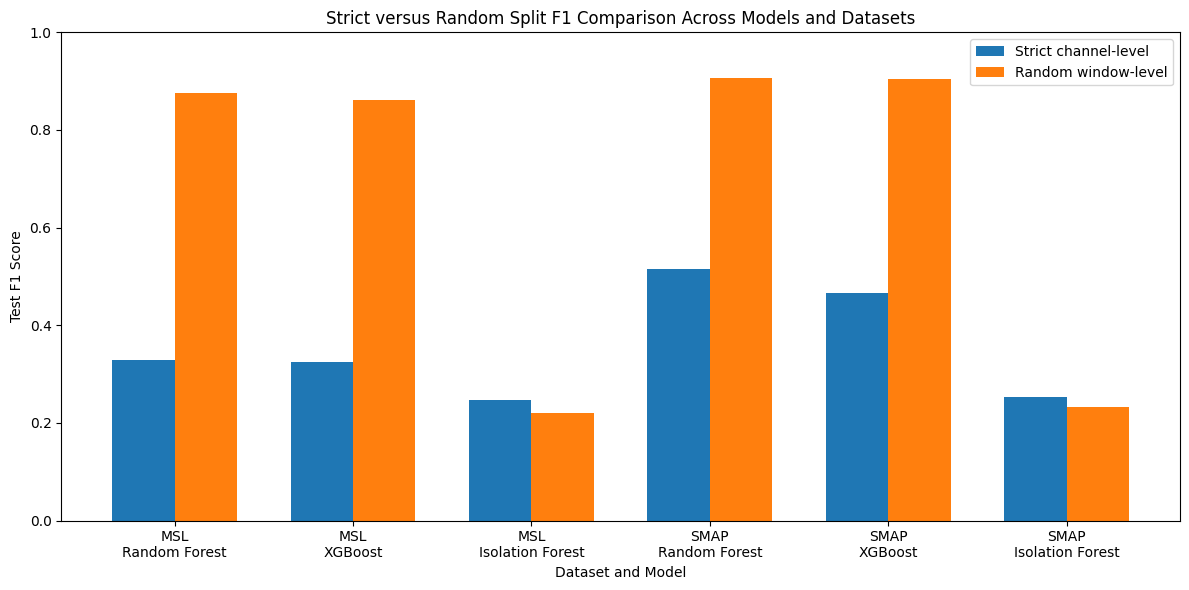

In [103]:
# Create a compact summary table for plotting how F1 changes between the strict and optimistic evaluation settings
# Create the strict split results table
strict_df = pd.DataFrame([
    {"dataset": "MSL",  "model": "Random Forest",    "test_f1": 0.3297},
    {"dataset": "MSL",  "model": "XGBoost",          "test_f1": 0.3240},
    {"dataset": "MSL",  "model": "Isolation Forest", "test_f1": 0.2464},
    {"dataset": "SMAP", "model": "Random Forest",    "test_f1": 0.5143},
    {"dataset": "SMAP", "model": "XGBoost",          "test_f1": 0.4659},
    {"dataset": "SMAP", "model": "Isolation Forest", "test_f1": 0.2533},
])

# Create the random window-level results table
random_df = pd.DataFrame([
    {"dataset": "MSL",  "model": "Random Forest",    "test_f1": 0.8748},
    {"dataset": "MSL",  "model": "XGBoost",          "test_f1": 0.8617},
    {"dataset": "MSL",  "model": "Isolation Forest", "test_f1": 0.2202},
    {"dataset": "SMAP", "model": "Random Forest",    "test_f1": 0.9074},
    {"dataset": "SMAP", "model": "XGBoost",          "test_f1": 0.9044},
    {"dataset": "SMAP", "model": "Isolation Forest", "test_f1": 0.2322},
])

# Merge both settings into one comparison table
comparison_df = strict_df.merge(
    random_df,
    on=["dataset", "model"],
    suffixes=("_strict", "_random")
)

comparison_df["label"] = comparison_df["dataset"] + "\n" + comparison_df["model"]

print(comparison_df)

# Plot strict vs random split F1 scores
x = np.arange(len(comparison_df))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, comparison_df["test_f1_strict"], width, label="Strict channel-level")
plt.bar(x + width/2, comparison_df["test_f1_random"], width, label="Random window-level")

plt.xticks(x, comparison_df["label"], rotation=0)
plt.ylabel("Test F1 Score")
plt.xlabel("Dataset and Model")
plt.title("Strict versus Random Split F1 Comparison Across Models and Datasets")
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

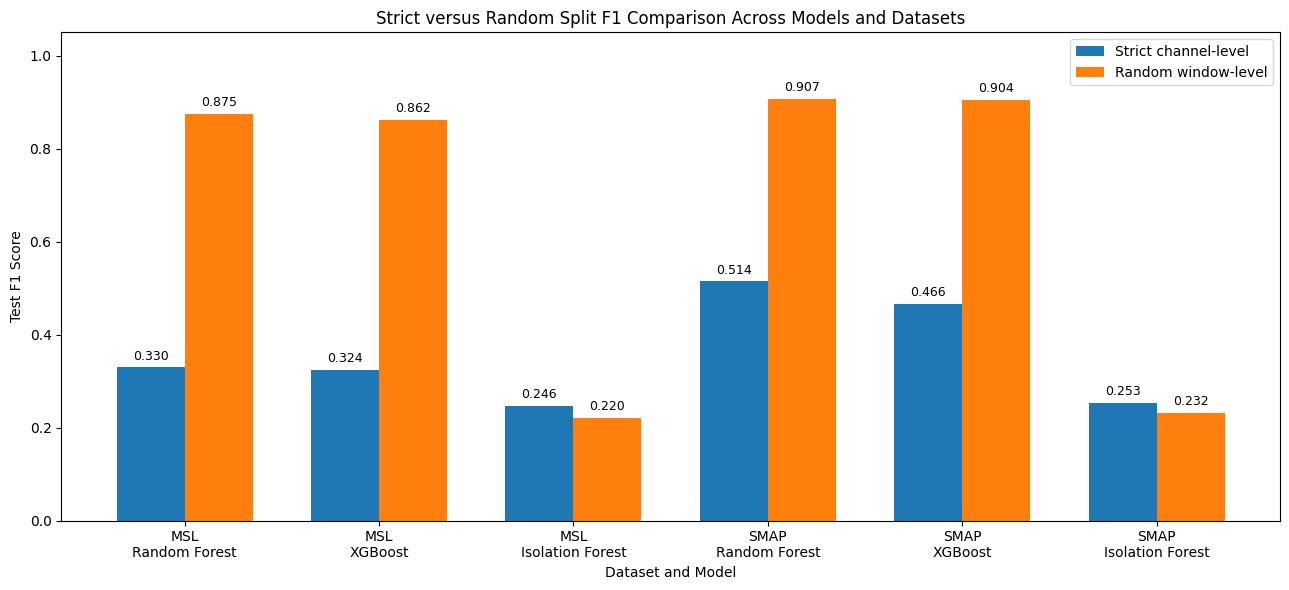

In [104]:
# Enter the strict channel-level test F1 scores
strict_df = pd.DataFrame([
    {"dataset": "MSL",  "model": "Random Forest",    "test_f1": 0.3297},
    {"dataset": "MSL",  "model": "XGBoost",          "test_f1": 0.3240},
    {"dataset": "MSL",  "model": "Isolation Forest", "test_f1": 0.2464},
    {"dataset": "SMAP", "model": "Random Forest",    "test_f1": 0.5143},
    {"dataset": "SMAP", "model": "XGBoost",          "test_f1": 0.4659},
    {"dataset": "SMAP", "model": "Isolation Forest", "test_f1": 0.2533},
])

# Enter the random window-level test F1 scores
random_df = pd.DataFrame([
    {"dataset": "MSL",  "model": "Random Forest",    "test_f1": 0.8748},
    {"dataset": "MSL",  "model": "XGBoost",          "test_f1": 0.8617},
    {"dataset": "MSL",  "model": "Isolation Forest", "test_f1": 0.2202},
    {"dataset": "SMAP", "model": "Random Forest",    "test_f1": 0.9074},
    {"dataset": "SMAP", "model": "XGBoost",          "test_f1": 0.9044},
    {"dataset": "SMAP", "model": "Isolation Forest", "test_f1": 0.2322},
])

# Merge both evaluation settings into one comparison table
comparison_df = strict_df.merge(
    random_df,
    on=["dataset", "model"],
    suffixes=("_strict", "_random")
)

comparison_df["label"] = comparison_df["dataset"] + "\n" + comparison_df["model"]

# Build the grouped bar chart
x = np.arange(len(comparison_df))
width = 0.35

plt.figure(figsize=(13, 6))

bars1 = plt.bar(
    x - width/2,
    comparison_df["test_f1_strict"],
    width,
    label="Strict channel-level"
)

bars2 = plt.bar(
    x + width/2,
    comparison_df["test_f1_random"],
    width,
    label="Random window-level"
)

# Add value labels above each bar
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=0
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=0
    )

# Final chart formatting
plt.xticks(x, comparison_df["label"])
plt.ylabel("Test F1 Score")
plt.xlabel("Dataset and Model")
plt.title("Strict versus Random Split F1 Comparison Across Models and Datasets")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

# Save the figure for the paper
plt.savefig("figure2_strict_vs_random_f1.png", dpi=300, bbox_inches="tight")

plt.show()

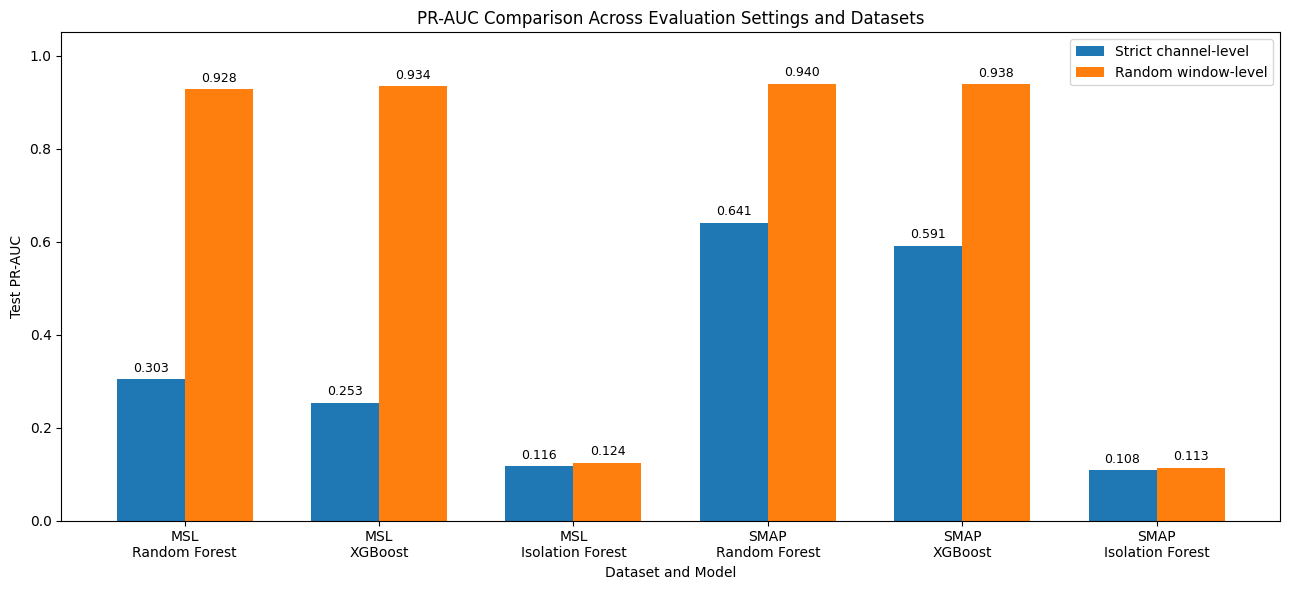

In [105]:
# Enter the strict channel-level test PR-AUC scores
# Create a compact summary table for plotting how PR-AUC changes between the strict and optimistic evaluation settings
strict_df = pd.DataFrame([
    {"dataset": "MSL",  "model": "Random Forest",    "test_pr_auc": 0.3035},
    {"dataset": "MSL",  "model": "XGBoost",          "test_pr_auc": 0.2529},
    {"dataset": "MSL",  "model": "Isolation Forest", "test_pr_auc": 0.1162},
    {"dataset": "SMAP", "model": "Random Forest",    "test_pr_auc": 0.6407},
    {"dataset": "SMAP", "model": "XGBoost",          "test_pr_auc": 0.5907},
    {"dataset": "SMAP", "model": "Isolation Forest", "test_pr_auc": 0.1082},
])

# Enter the random window-level test PR-AUC scores
random_df = pd.DataFrame([
    {"dataset": "MSL",  "model": "Random Forest",    "test_pr_auc": 0.9276},
    {"dataset": "MSL",  "model": "XGBoost",          "test_pr_auc": 0.9338},
    {"dataset": "MSL",  "model": "Isolation Forest", "test_pr_auc": 0.1239},
    {"dataset": "SMAP", "model": "Random Forest",    "test_pr_auc": 0.9395},
    {"dataset": "SMAP", "model": "XGBoost",          "test_pr_auc": 0.9381},
    {"dataset": "SMAP", "model": "Isolation Forest", "test_pr_auc": 0.1131},
])

# Merge both evaluation settings into one comparison table
comparison_df = strict_df.merge(
    random_df,
    on=["dataset", "model"],
    suffixes=("_strict", "_random")
)

comparison_df["label"] = comparison_df["dataset"] + "\n" + comparison_df["model"]

# Build the grouped bar chart
x = np.arange(len(comparison_df))
width = 0.35

plt.figure(figsize=(13, 6))

bars1 = plt.bar(
    x - width/2,
    comparison_df["test_pr_auc_strict"],
    width,
    label="Strict channel-level"
)

bars2 = plt.bar(
    x + width/2,
    comparison_df["test_pr_auc_random"],
    width,
    label="Random window-level"
)

# Add value labels above each bar
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

# Final chart formatting
plt.xticks(x, comparison_df["label"])
plt.ylabel("Test PR-AUC")
plt.xlabel("Dataset and Model")
plt.title("PR-AUC Comparison Across Evaluation Settings and Datasets")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()

# Save the figure for the paper
plt.savefig("figure3_strict_vs_random_pr_auc.png", dpi=300, bbox_inches="tight")

plt.show()